# The Volatility Surface

*orientation, the observation set, and where a hypothesis comes from*

## The question

Before any model, three questions have to be settled in order: **what is being
observed, how much of it is real, and what pattern in it is worth a hypothesis.** This
notebook settles all three on the SPY option smile, and sets up the environment the rest of
the series runs in. It ends where the argument begins — with a shape in the data that a model
should be able to explain.

### Orientation

**This series is about volatility: how it is modelled, how its parameters are estimated, and
how you decide whether a model is telling you anything.** It is organised as a research
programme in four parts rather than as a list of procedures — because the order in which
questions are asked *is* the method, and a technique shown outside that order teaches very
little.

| Part | Notebooks | The question it works |
|---|---|---|
| **I · A volatility model, and whether it holds** | The Volatility Surface → When a Result Is Real | What does a volatility model claim, what parameter does the claim turn on, and does it survive estimation, forecasting and hedging? The worked hypothesis is *rough volatility* — that volatility is far more jagged than a diffusion, with Hurst exponent H ≈ 0.1. |
| **II · The cross-sectional design** | The Cross-Section | The same methodology under a different design: many entities on one date rather than one series through time. A different estimand (a ranking), a different validation (purged by date), a different metric (rank IC). |
| **III · Method in depth** | Where the Numbers Come From → Measuring and Trading Volatility | Each technique the first two parts leaned on, treated on its own terms — provenance, measurement error, evidence and display, combining sources, the volatility estimators themselves, turning a model into a position, and the inference neither part had to reach for. |
| **IV · Competition workbench** | Competition Workbench | The reusable contract, split router, OOF ledger, null controls, validated submission and evidence bundle for structured-data competitions. |

Negative results are kept, not buried. Part I reaches a mostly-negative verdict on rough
volatility, and **how** that verdict was reached is more transferable than a positive one
would have been: the same sequence works on any claim about a market.

**The series is also usable as a reference.** Every notebook is built from numbered *recipes*
— small, self-contained, copy-pasteable blocks, each labelled with the technique it
demonstrates and each verified to run on its own. When a task lands and the clock is running,
the index in [`README.md`](README.md) is the entry point: search a technique or a topic and
land on a runnable cell. Reading the parts in order gives you the method; the index gives you
the ingredient.

Read this notebook once. After that, use the index.

### What is being observed

An option smile is three numbers at each maturity: a **level** (`atm_iv`), a **slope**
(`rr25`, the 25-delta risk reversal) and a **curvature** (`bf25`, the 25-delta butterfly).
Everything in this series is a function of those three plus the time to expiry `T`.

Before asking whether rough volatility describes them, we have to answer a duller question
that decides whether anything downstream is real: **what exactly is in this file, where did
it come from, and does it say what we think it says?** Most analyses that go wrong go wrong
here, silently, and the error surfaces three notebooks later disguised as a finding.

### The first look

An implied volatility is not observed. It is *solved for*, by inverting an option price
through Black-Scholes. That makes every smile feature a derived quantity, and derived
quantities inherit every defect of their inputs — a stale quote, a crossed market, a wide
spread on an illiquid wing — and then amplify them.

So before asking what the smile does, ask how much of it is real. This notebook is the
quality pass: where the holes are, which observations are implausible rather than merely
extreme, and what the three smile features look like when you finally plot them.

In [1]:
try:
    import rvlab
except ModuleNotFoundError:
    import pathlib, sys
    _root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src" / "rvlab").is_dir())
    sys.path.insert(0, str(_root / "src"))
    import rvlab
rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,/Users/xiaohao/Effective_Engine/MVP/demo/python/research/shared
● smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
● smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
● smile_5d,Near-tenor only.
● chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## Parameters

In [2]:
SHOW_FULL_CATALOGUE = True   # False prints only the datasets that are present
DATASET   = "smile_90d"    # "smile_90d" | "smile_127d" | "smile_5d" | see rvlab.data.available()
MIN_DTE   = 7              # calendar days; shorter options are dominated by microstructure
MAX_DTE   = 60             # longer ones leave the liquid short-dated regime
SHOW_ROWS = 5
MIN_DTE, MAX_DTE = 7, 60
WINSOR_Q    = (0.01, 0.99)   # clip quantiles for the robust-stats recipe
CORR_METHOD = "spearman"     # rank correlation: heavy tails make Pearson unreliable

## Where the data comes from

This notebook covers several sections, and each one loads what it needs at its own head — the cell below for the first section, and one like it under every heading after that. They are the only cells that read data: change them and the whole section re-aims at your own frames, with every recipe below unchanged.

In [3]:
from rvlab.data import load_smile_panel

df = load_smile_panel("smile_5d")   # the small one; this notebook only needs a shape
df.head(3)

,ts,expiry,T,atm_iv,atm_total_var,rr25,bf25,alpha,gamma
0,2025-08-07 13:35:00+00:00,2025-08-14,0.0192,0.1246,0.0003,-0.0329,0.0032,-0.0542,0.4615
1,2025-08-07 13:35:00+00:00,2025-08-15,0.0219,0.1278,0.0004,-0.0341,0.0026,-0.0578,0.3394
2,2025-08-07 13:36:00+00:00,2025-08-14,0.0192,0.1246,0.0003,-0.0332,0.0036,-0.0548,0.5149


## Recipes in this notebook

**Orientation**

| Recipe | What it does |
|---|---|
| [R1.1](#r1-1) | Check the environment before blaming the analysis |
| [R1.2](#r1-2) | See which datasets are present, and what happens when they are not |
| [R1.3](#r1-3) | Force the synthetic path to test reproducibility |
| [R1.4](#r1-4) | Find the recipe you need |
| [R1.5](#r1-5) | Understand the shape every notebook shares |

**What is being observed**

| Recipe | What it does |
|---|---|
| [R1.6](#r1-6) | Find out what data this machine actually has |
| [R1.7](#r1-7) | Make every frame carry its own provenance |
| [R1.8](#r1-8) | Read a CSV without letting pandas guess |
| [R1.9](#r1-9) | Shrink a frame without losing anything |
| [R1.10](#r1-10) | Get timezones right once, at the boundary |
| [R1.11](#r1-11) | State a schema contract and check it |
| [R1.12](#r1-12) | Write a contract for your own data |
| [R1.13](#r1-13) | Describe a panel in one look |

**The first look**

| Recipe | What it does |
|---|---|
| [R1.14](#r1-14) | Look at distributions before looking at relationships |
| [R1.15](#r1-15) | Map the missing values before deciding what to do about them |
| [R1.16](#r1-16) | Choose an imputation strategy on purpose |
| [R1.17](#r1-17) | Winsorize rather than delete |
| [R1.18](#r1-18) | Check quote sanity before trusting a derived value |
| [R1.19](#r1-19) | Detect stale quotes |
| [R1.20](#r1-20) | Resample an irregular panel without inventing observations |
| [R1.21](#r1-21) | Join two time series on time, correctly |
| [R1.22](#r1-22) | Read a correlation matrix with the right correlation |
| [R1.23](#r1-23) | Plot the object you are actually modelling |

Each recipe is self-contained: it uses only the names its section's data cell binds, plus the parameters cell and anything it declares under **Needs**. Copy any one of them straight into another project.

## Things to watch

Every item below is something that fails *quietly* in this notebook's material — no exception, no warning, just a number that is wrong.

**Python and pandas**

* **`read_csv` guesses, and one stray string is enough.** A numeric column with a single
  `"n/a"` becomes `object`, and every later `.mean()` is either an error or a surprise.
  Declare `dtype=` and `parse_dates=`; let the read fail loudly instead.
* **`df.attrs` does not survive `concat` or `merge`.** Provenance attached at load time is
  gone by the time you quote a number, unless you re-attach it. Check it at the point of use,
  not the point of load.
* **Chained assignment writes to a copy.** `df[mask]["x"] = v` silently does nothing on a
  copy; `df.loc[mask, "x"] = v` is the version that works. Pandas 3 makes this an error —
  until then it is a silent no-op.
* **`groupby` on a `Categorical` yields unobserved combinations** unless you pass
  `observed=True`, which is how empty groups turn into rows of NaN you then average over.
* **`.describe()` omits the null count.** It is the one number you most need; `.isna().sum()`
  or a health report gets it.
* **Never compare floats with `==`.** Timestamps parsed two ways, or a price round-tripped
  through CSV, differ in the last bits. `np.isclose` with an explicit tolerance.

**Analysis**

* **An implied volatility is solved for, not observed.** Every smile feature inherits the
  defects of the quote it was inverted from, then amplifies them. Treat it as a derived
  quantity with an error bar, not as data.
* **"Extreme" and "implausible" are different words.** A five-sigma move in a fat-tailed
  series is ordinary. Drop an observation because a *mechanism* says it is wrong — a crossed
  market, a stale timestamp — not because it is far from the mean.
* **Winsorising and dropping are not interchangeable.** Clipping keeps the row and moves the
  value; dropping keeps the value and moves the sample. Say which you did and why.
* **Use rank correlation when the tails are heavy.** Pearson on this data is a statement about
  a handful of observations.
* **Look at the data before believing any summary of it.** Every number in this notebook's
  verdict was visible in a plot first; that ordering is not decoration.


## Orientation

What this machine has, what runs without it, and how to find a recipe by name. Nothing here depends on market data being present — that is the point of it.

## R1.1 · Check the environment before blaming the analysis
<a id="r1-1"></a>

**Topic** Environment

**Use when** the first cell of any session. `setup_notebook()` returns a report of what this machine has: library versions, where the external `roughvol` package resolved, and which datasets are on disk.

**Inputs** nothing.

**Needs** nothing beyond the setup and data cells

**Gotchas** if `roughvol` shows as not found, the rough-volatility simulation and hedging recipes fall back to rvlab's own implementations rather than failing — the results stay valid but the schemes differ. The report is the only place that difference is visible.

**See also** [R1.2](#r1-2) (data availability) · [R1.7](the_volatility_surface.ipynb#r1-7) (provenance)

In [4]:
import rvlab

rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,/Users/xiaohao/Effective_Engine/MVP/demo/python/research/shared
● smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
● smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
● smile_5d,Near-tenor only.
● chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## R1.2 · See which datasets are present, and what happens when they are not
<a id="r1-2"></a>

**Topic** Data discovery

**Use when** before running the series on a new machine. The SPY market data is gitignored, so a fresh clone has none of it.

**Inputs** nothing.

**Needs** nothing beyond the setup and data cells

**Gotchas** missing data is **not** an error here. Every loader falls back to a synthetic panel with the same schema and stamps `synthetic: True` on the frame, so notebooks always execute. What changes is the epistemic status of the output, not whether it runs.

**See also** [R1.3](#r1-3) (forcing the fallback) · [R1.6](the_volatility_surface.ipynb#r1-6) (catalogue)

In [5]:
from rvlab.data import available

catalogue = available()
catalogue if SHOW_FULL_CATALOGUE else catalogue[catalogue["present"]]

,dataset_id,present,size_mb,kind,description,tenor
0,smile_90d,True,57.0,pickle-records,"SPY smile features, 90 trading days, all expir...","Multi-maturity: T in [0.019, 0.164]. The term-..."
1,smile_127d,True,12.1,pickle-records,"SPY smile features, 127 trading days, front ex...",Near-tenor only: T ~ 0.02-0.03. The long-histo...
2,smile_5d,True,0.5,pickle-records,"SPY smile features, 5 trading days. Small and ...",Near-tenor only.
3,chain_panel,True,0.4,csv,"SPY 1-minute ATM chain panel, 26 columns incl....","2025-08-07 to 2025-08-13, one expiry per bar."


## R1.3 · Force the synthetic path to test reproducibility
<a id="r1-3"></a>

**Topic** Reproducibility

**Use when** you want to know whether a notebook depends on data a colleague will not have. Setting `RVLAB_FORCE_SYNTHETIC=1` makes every loader ignore local caches.

**Inputs** nothing.

**Needs** nothing beyond the setup and data cells

**Gotchas** the synthetic generator plants a *known* rough structure with a known H. That makes it the right dataset for validating an estimator ([R2.12](what_roughness_claims.ipynb#r2-12) uses it exactly this way) and the wrong one for drawing any conclusion about markets.

**See also** [R1.2](#r1-2) (availability) · [R2.12](what_roughness_claims.ipynb#r2-12) (estimator bias on known ground truth)

In [6]:
import os
from rvlab.data import describe_provenance, load_smile_panel

os.environ["RVLAB_FORCE_SYNTHETIC"] = "1"
print("forced  :", describe_provenance(load_smile_panel("smile_5d")))

os.environ.pop("RVLAB_FORCE_SYNTHETIC", None)
print("default :", describe_provenance(load_smile_panel("smile_5d")))

forced  : smile_5d: 1,677 rows from SYNTHETIC | 2026-01-05 13:35:00+00:00 -> 2026-01-12 14:45:00+00:00
default : smile_5d: 3,810 rows from /Users/xiaohao/Effective_Engine/MVP/demo/python/research/cache/gate0_days5_farF.pkl | 2025-08-07 13:35:00+00:00 -> 2025-08-13 19:55:00+00:00


## R1.4 · Find the recipe you need
<a id="r1-4"></a>

**Topic** Navigation

**Use when** you have a task ('impute missing values', 'purged CV split', 'block bootstrap CI') and want the cell that does it. This lists every recipe in the series, in one frame you can filter.

**Inputs** the notebooks directory.

**Needs** nothing beyond the setup and data cells

**Gotchas** the same table lives in [`README.md`](README.md) with working links, grouped into eleven families — the better entry point when you are browsing rather than running. Here the topic is a flat string, so search it together with the technique.

**See also** [README.md](README.md)

In [7]:
import json, pathlib, re, pandas as pd

# Find the notebooks directory from wherever this is being run.
nb_dir = next(d / "notebooks" for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (d / "notebooks").is_dir())

heading = re.compile(r"^##\s+(R\d+\.\d+)\s+·\s+(.+?)\s*$", re.M)
topic = re.compile(r"^\*\*Topic\*\*\s*(.+?)\s*$", re.M)

def cards(path):
    """Every recipe card in one notebook, as index rows."""
    for c in json.loads(path.read_text())["cells"]:
        if c["cell_type"] != "markdown":
            continue
        text = "".join(c["source"])
        for rid, title in heading.findall(text):
            t = topic.search(text)
            yield {"recipe": rid, "topic": t.group(1).strip() if t else "",
                   "technique": title, "notebook": path.stem}

# Reading order lives in .order, not in the filenames — read it so the frame comes
# back in the order a reader would meet the recipes.
order = [ln.strip() for ln in (nb_dir / ".order").read_text().split("\n") if ln.strip()]
recipes = pd.DataFrame([r for f in order for r in cards(nb_dir / f)])
print(f"{len(recipes)} recipes · {recipes.notebook.nunique()} notebooks · "
      f"{recipes.topic.nunique()} distinct topics")
recipes.head(12)

237 recipes · 9 notebooks · 98 distinct topics


,recipe,topic,technique,notebook
0,R1.1,Environment,Check the environment before blaming the analysis,the_volatility_surface
1,R1.2,Data discovery,"See which datasets are present, and what happe...",the_volatility_surface
2,R1.3,Reproducibility,Force the synthetic path to test reproducibility,the_volatility_surface
3,R1.4,Navigation,Find the recipe you need,the_volatility_surface
4,R1.5,Navigation,Understand the shape every notebook shares,the_volatility_surface
5,R1.6,Data discovery,Find out what data this machine actually has,the_volatility_surface
6,R1.7,Provenance,Make every frame carry its own provenance,the_volatility_surface
7,R1.8,File I/O,Read a CSV without letting pandas guess,the_volatility_surface
8,R1.9,Memory,Shrink a frame without losing anything,the_volatility_surface
9,R1.10,Timezones,"Get timezones right once, at the boundary",the_volatility_surface


Filter on **topic and technique together** — the topic is the vocabulary the index is organised by, the technique is how the recipe is phrased, and a task name usually hits one or the other. Change the search term to whatever you are actually looking for.

In [8]:
term = "split|bootstrap|impute"        # <- whatever you are looking for

searchable = recipes["topic"] + " · " + recipes["technique"]
recipes[searchable.str.contains(term, case=False)]

,recipe,topic,technique,notebook
48,R3.11,Cross-validation,Choose a splitter that matches the data's stru...,forecasting_the_smile
79,R4.20,Backtesting,Walk forward instead of splitting once,when_a_result_is_real
97,R5.16,Cross-validation,"Split dates, not rows — then map back to row i...",the_cross_section


## R1.5 · Understand the shape every notebook shares
<a id="r1-5"></a>

**Topic** Navigation

**Use when** you are about to open any other notebook and want to know where things are. All nine share the same skeleton, so the structure is worth learning once.

**Inputs** nothing.

**Needs** nothing beyond the setup and data cells

**Gotchas** the `parameters` and `swap-data` tags are load-bearing, not decoration: `scripts/lint_notebooks.py` requires exactly one of each, and the copy-paste test uses them as the preamble when it checks that every recipe runs in isolation.

**See also** [R1.4](#r1-4) (finding a recipe)

In [9]:
structure = [
    ("The question",   "why this notebook exists, in a paragraph. No code."),
    ("Setup",          "the same four lines everywhere; tagged `setup`."),
    ("Parameters",     "every knob, in one cell; tagged `parameters`."),
    ("Swap in your own data", "the only place data enters; tagged `swap-data`."),
    ("Recipes",        "`## R<n> · technique`, each with Use when / Inputs / Gotchas."),
    ("Verdict",        "what was established, and what carries into the next notebook."),
]
import pandas as pd
pd.DataFrame(structure, columns=["section", "what it is"])

,section,what it is
0,The question,"why this notebook exists, in a paragraph. No c..."
1,Setup,the same four lines everywhere; tagged `setup`.
2,Parameters,"every knob, in one cell; tagged `parameters`."
3,Swap in your own data,the only place data enters; tagged `swap-data`.
4,Recipes,"`## R<n> · technique`, each with Use when / In..."
5,Verdict,"what was established, and what carries into th..."


## What is being observed

The smile panel as an observation set: what the file contains, where it came from, and whether it says what we think. Read the contract before trusting the column.

Its data cell binds `df`.

In [10]:
from rvlab.data import load_smile_panel

df = load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE)
df.head(SHOW_ROWS)

,ts,expiry,T,forward,atm_iv,atm_total_var,rr25,bf25,alpha,gamma
0,2025-08-07 13:35:00+00:00,2025-08-14,0.0192,637.2250,0.1246,0.0003,-0.0329,0.0033,-0.0542,0.4616
1,2025-08-07 13:35:00+00:00,2025-08-15,0.0219,637.4100,0.1278,0.0004,-0.0341,0.0026,-0.0578,0.3394
2,2025-08-07 13:35:00+00:00,2025-08-18,0.0301,637.5450,0.1159,0.0004,-0.0339,0.0045,-0.0721,0.6796
3,2025-08-07 13:35:00+00:00,2025-08-19,0.0329,637.6200,0.1171,0.0005,-0.0357,0.0050,-0.0777,0.7241
4,2025-08-07 13:35:00+00:00,2025-08-20,0.0356,637.6975,0.1186,0.0005,-0.0369,0.0050,-0.0821,0.6954


## R1.6 · Find out what data this machine actually has
<a id="r1-6"></a>

**Topic** Data discovery

**Use when** you are opening a project on a new machine, or a loader just silently returned something unexpected. Check availability *before* debugging analysis code.

**Inputs** nothing.

**Needs** nothing beyond the setup and data cells

**Gotchas** a dataset that is `present` is not necessarily *correct* — this only checks that the file exists and how large it is. Market data here is gitignored, so a fresh clone shows everything missing and every notebook quietly switches to synthetic data.

**See also** [R1.7](#r1-7) (provenance) · [R1.11](#r1-11) (contracts)

In [11]:
from rvlab.data import available

available()[["dataset_id", "present", "size_mb", "tenor"]]

,dataset_id,present,size_mb,tenor
0,smile_90d,True,57.0,"Multi-maturity: T in [0.019, 0.164]. The term-..."
1,smile_127d,True,12.1,Near-tenor only: T ~ 0.02-0.03. The long-histo...
2,smile_5d,True,0.5,Near-tenor only.
3,chain_panel,True,0.4,"2025-08-07 to 2025-08-13, one expiry per bar."


## R1.7 · Make every frame carry its own provenance
<a id="r1-7"></a>

**Topic** Provenance

**Use when** a number in a notebook needs to be traceable to a file. Attaching provenance to the frame itself means you can print it anywhere downstream without threading a variable through every function.

**Inputs** `df` from any `rvlab.data` loader.

**Needs** nothing beyond the setup and data cells

**Gotchas** `df.attrs` survives most pandas operations but is **dropped by merges and concats**. Re-stamp after those, or keep provenance in a separate variable if it matters.

**See also** [R1.6](#r1-6) (what exists) · [R1.11](#r1-11) (contracts)

In [12]:
from rvlab.data import describe_provenance, provenance

print(describe_provenance(df))
provenance(df)

smile_90d: 380,857 rows from /Users/xiaohao/Effective_Engine/MVP/demo/python/research/cache/gate0b_days90_farF.pkl | 2025-08-07 13:35:00+00:00 -> 2025-12-12 19:55:00+00:00


{'rows': 380857,
 'dataset_id': 'smile_90d',
 'path': '/Users/xiaohao/Effective_Engine/MVP/demo/python/research/cache/gate0b_days90_farF.pkl',
 'synthetic': False,
 'sha256': '0d336d296e0a6c30',
 'ts_min': '2025-08-07 13:35:00+00:00',
 'ts_max': '2025-12-12 19:55:00+00:00',
 'n_timestamps': 32558,
 'n_expiries': 100}

The `synthetic` flag is the one to check before quoting a number to anyone. `sha256` is a prefix hash of the source file — enough to notice that an input changed underneath a saved result.

In [13]:
if provenance(df).get("synthetic"):
    print("⚠️  SYNTHETIC data — numbers below are illustrative, not empirical")
else:
    print(f"real data · sha256[:16] = {provenance(df)['sha256']}")

real data · sha256[:16] = 0d336d296e0a6c30


## R1.8 · Read a CSV without letting pandas guess
<a id="r1-8"></a>

**Topic** File I/O

**Use when** loading any delimited file. Left to itself pandas will infer dtypes from the first rows, read dates as strings, and turn an integer column with one missing value into a float. Declare instead of infer.

**Inputs** a CSV path. Here: the 26-column SPY 1-minute chain panel.

**Needs** nothing beyond the setup and data cells

**Gotchas** `parse_dates` alone does not set a timezone — a naive timestamp compared against a UTC one raises, or worse, silently misaligns by hours. Convert explicitly.

**See also** [R1.9](#r1-9) (dtypes and memory) · [R1.10](#r1-10) (timezones)

In [14]:
from rvlab.data import load_chain_panel

chain = load_chain_panel()          # parse_dates + explicit expiry conversion inside
chain[["timestamp_utc", "underlying_price", "atm_iv", "call_bid", "call_ask"]].head(3)

,timestamp_utc,underlying_price,atm_iv,call_bid,call_ask
0,2025-08-07 13:31:00+00:00,636.635,0.1169,4.96,4.99
1,2025-08-07 13:32:00+00:00,636.905,0.1162,5.06,5.10
2,2025-08-07 13:33:00+00:00,637.530,0.1169,5.41,5.45


The equivalent written out, for a file of your own. The key moves are `dtype=` (declare, don't infer), `parse_dates=` (dates as dates) and `usecols=` (never read columns you will not use — it is the cheapest speed-up available on a wide file).

In [15]:
import io, pandas as pd

sample = io.StringIO("ts,price,volume,flag\n2025-08-07T13:31:00Z,636.6,1200,A\n")
pd.read_csv(sample, usecols=["ts", "price", "volume"],
            dtype={"price": "float64", "volume": "int32"},
            parse_dates=["ts"]).dtypes.to_frame("dtype")

,dtype
ts,"datetime64[ns, UTC]"
price,float64
volume,int32


## R1.9 · Shrink a frame without losing anything
<a id="r1-9"></a>

**Topic** Memory

**Use when** a frame is large enough that operations feel slow, or it will not fit in memory. Downcasting floats and converting low-cardinality strings to `category` routinely halves the footprint.

**Inputs** any DataFrame.

**Needs** nothing beyond the setup and data cells

**Gotchas** `float32` has ~7 significant digits. That is fine for prices and vols and **not** fine for accumulating sums, or for a value like `atm_total_var` that is already 1e-4 in size. Downcast the columns you display, not the ones you compute with.

**See also** [R1.8](#r1-8) (reading) · [R1.14](the_volatility_surface.ipynb#r1-14) (first look)

In [16]:
import numpy as np

before = df.memory_usage(deep=True).sum() / 1e6
small = df.copy()
for col in small.select_dtypes("float64"):
    small[col] = small[col].astype("float32")
small["expiry"] = small["expiry"].astype("category")

print(f"{before:.1f} MB -> {small.memory_usage(deep=True).sum() / 1e6:.1f} MB")

42.7 MB -> 15.6 MB


> ⚠️ **Precision:** check what the cast actually cost before keeping it. A relative error of 1e-7 is invisible in a plot and can still dominate a difference of two nearly-equal numbers.

In [17]:
rel_err = ((small["atm_total_var"].astype("float64") - df["atm_total_var"]).abs()
           / df["atm_total_var"].abs()).max()
print(f"worst relative error from float32: {rel_err:.2e}")

worst relative error from float32: 5.96e-08


## R1.10 · Get timezones right once, at the boundary
<a id="r1-10"></a>

**Topic** Timezones

**Use when** any intraday data. Convert to UTC at load time and keep it UTC internally; convert to a local zone only for display. Mixing naive and aware timestamps is a runtime error at best and a silent misalignment at worst.

**Inputs** `df` with a tz-aware `ts` column.

**Needs** nothing beyond the setup and data cells

**Gotchas** US market sessions do not start at a fixed UTC hour — daylight saving moves them by an hour twice a year. Deriving 'minutes since the open' from a UTC clock breaks across that boundary unless you convert to the exchange's zone first.

**See also** [R1.8](#r1-8) (reading) · [R1.18](the_volatility_surface.ipynb#r1-18) (session boundaries)

In [18]:
print("tz:", df["ts"].dt.tz, "| span:", df["ts"].min(), "->", df["ts"].max())

et = df["ts"].dt.tz_convert("America/New_York")
et.dt.strftime("%H:%M").value_counts().sort_index().head(4).to_frame("bars")

tz: UTC | span: 2025-08-07 13:35:00+00:00 -> 2025-12-12 19:55:00+00:00


,bars
ts,
09:31,344
09:32,344
09:33,344
09:34,344


The first and last bar of the session in exchange time. If these are not 09:30–16:00 give or take a few minutes, the panel is filtered somehow — worth knowing before you interpret an intraday pattern.

In [19]:
print(f"session in exchange time: {et.dt.strftime('%H:%M').min()} "
      f"-> {et.dt.strftime('%H:%M').max()}")

session in exchange time: 09:31 -> 15:55


## R1.11 · State a schema contract and check it
<a id="r1-11"></a>

**Topic** Data contracts

**Use when** always, immediately after loading, and again after any pipeline that reshapes data. A contract turns 'the analysis produced a weird number' into 'row 4,132 has a negative implied vol', which is a bug you can fix in a minute.

**Inputs** `df`, and a `SchemaSpec` describing what it must satisfy.

**Needs** nothing beyond the setup and data cells

**Gotchas** `validate` never raises — it returns a report. That is deliberate, so you can look at *all* the violations at once. Call `.raise_if_failed()` when you want it to stop.

**See also** [R1.12](#r1-12) (writing your own) · [R1.15](the_volatility_surface.ipynb#r1-15) (missing values)

In [20]:
from rvlab.data import SMILE_PANEL

SMILE_PANEL.validate(df)

ValidationReport(name='smile_panel', n_rows=380857, errors=[], warnings=[])

Contracts catch real problems. Here is the same check against a frame with a planted error — a negative implied volatility, which is not a number that can exist, and which would otherwise propagate into every downstream feature.

In [21]:
broken = df.head(1000).copy()
broken.loc[broken.index[:3], "atm_iv"] = -0.5

print(SMILE_PANEL.validate(broken))

[FAIL] smile_panel — 1,000 rows
  error   : column 'atm_iv': 3 values outside [0.01, 3.0] (observed -0.5..0.1391)


## R1.12 · Write a contract for your own data
<a id="r1-12"></a>

**Topic** Data contracts

**Use when** your frame is not a smile panel. `SchemaSpec` is declarative: name the columns, their kinds, the ones that must not be null, the plausible ranges, and what must be unique.

**Inputs** nothing — it is a specification, applied to a frame later.

**Needs** nothing beyond the setup and data cells

**Gotchas** ranges are the highest-value part and the part people skip. 'price > 0' and '0 <= probability <= 1' catch more real bugs than any dtype check.

**See also** [R1.11](#r1-11) (using contracts)

In [22]:
from rvlab.data import SchemaSpec

my_contract = SchemaSpec(
    name="my_quotes",
    columns={"ts": "datetime", "price": "float", "size": "int"},
    non_null=("ts", "price"),
    ranges={"price": (0.01, 1e6), "size": (0, 1e9)},
    unique=(("ts",),),
    sorted_by="ts",
)
my_contract

SchemaSpec(name='my_quotes', columns={'ts': 'datetime', 'price': 'float', 'size': 'int'}, non_null=('ts', 'price'), ranges={'price': (0.01, 1000000.0), 'size': (0, 1000000000.0)}, unique=(('ts',),), sorted_by='ts')

Applied to a deliberately broken frame, so you can see each rule fire.

In [23]:
import pandas as pd

bad = pd.DataFrame({"ts": pd.to_datetime(["2026-01-02", "2026-01-01", "2026-01-01"], utc=True),
                    "price": [10.0, -3.0, None], "size": [1, 2, 3]})
print(my_contract.validate(bad))

[FAIL] my_quotes — 3 rows
  error   : column 'price' has 1 null values
  error   : column 'price': 1 values outside [0.01, 1000000.0] (observed -3..10)
  error   : 1 duplicate rows on ['ts']


## R1.13 · Describe a panel in one look
<a id="r1-13"></a>

**Topic** Exploratory summary

**Use when** you have just loaded something and want the shape of it in one line rather than five `print` statements. Shape, span, coverage and level, together.

**Inputs** `df` with `ts`, `expiry`, `T` and the three smile columns.

**Needs** nothing beyond the setup and data cells

**Gotchas** `expiries_per_ts` is the number that decides whether the term-structure fit in [R2.9](what_roughness_claims.ipynb#r2-9) is possible at all. One expiry per timestamp means there is no cross-section to regress, and every maturity result becomes a time-series result instead.

**See also** [R1.14](the_volatility_surface.ipynb#r1-14) (distributions) · [R2.9](what_roughness_claims.ipynb#r2-9) (term structure fit)

In [24]:
from rvlab.features import summarise_panel

summarise_panel(df)

,value
metric,
rows,380857.0000
timestamps,32558.0000
expiries,100.0000
expiries_per_ts,11.7000
dte_min,7.0000
dte_max,60.0000
atm_iv_median,0.1314
rr25_median,-0.0446
bf25_median,0.0049


## The first look

How much of the panel is usable, and what pattern in it is worth a hypothesis. Quality work and exploratory work are the same work here — the defects and the signal show up in the same plots.

Its data cell binds `chain`, `df`.

In [25]:
from rvlab.data import load_chain_panel, load_smile_panel

df = load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE)
chain = load_chain_panel()
print(f"panel {df.shape}   chain {chain.shape}")

panel (380857, 10)   chain (2029, 26)


## R1.14 · Look at distributions before looking at relationships
<a id="r1-14"></a>

**Topic** Exploratory analysis

**Use when** immediately after loading. `describe()` on the columns you will actually model, with the percentiles that matter for tails — not the default quartiles.

**Inputs** `df` with numeric feature columns.

**Needs** nothing beyond the setup and data cells

**Gotchas** the mean of a heavy-tailed column is a summary of its outliers. Read the median and the 1%/99% points instead; if mean and median disagree materially, that is the finding.

**See also** [R1.15](#r1-15) (missingness) · [R1.17](#r1-17) (outliers)

In [26]:
cols = ["T", "atm_iv", "atm_total_var", "rr25", "bf25"]

df[cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
T,380857.0,0.0606,0.0401,0.0192,1.9178e-02,0.0301,0.0411,0.0877,0.1616,0.1644
atm_iv,380857.0,0.1348,0.0233,0.0792,9.8516e-02,0.1186,0.1314,0.1449,0.2092,0.2574
atm_total_var,380857.0,0.0012,0.0010,0.0001,2.0145e-04,0.0004,0.0008,0.0017,0.0041,0.0066
rr25,380857.0,-0.0458,0.0128,-0.1084,-8.4500e-02,-0.0521,-0.0446,-0.0364,-0.0252,-0.0095
bf25,380857.0,0.0048,0.0020,-0.0244,-3.6584e-05,0.0034,0.0049,0.0063,0.0089,0.0372


Three facts to read off this table, each of which shapes later notebooks:

* `rr25` is **negative** almost everywhere — puts cost more than calls. That is the equity skew, and it is the sign the rough model has to reproduce.
* `bf25` is small and positive — the wings sit above ATM.
* `atm_total_var` is O(1e-4), so absolute errors on it are meaningless without a scale. Every later score is a *relative* one for this reason.

In [27]:
skew_negative = (df["rr25"] < 0).mean()
print(f"rr25 < 0 in {skew_negative:.1%} of observations")
print(f"bf25 > 0 in {(df['bf25'] > 0).mean():.1%} of observations")

rr25 < 0 in 100.0% of observations
bf25 > 0 in 99.0% of observations


## R1.15 · Map the missing values before deciding what to do about them
<a id="r1-15"></a>

**Topic** Missing data

**Use when** any frame with gaps. The *pattern* of missingness decides the fix: a column that fails everywhere is a broken feature; whole rows failing together is a data outage. Those need different responses and a single 'percent missing' number hides the difference.

**Inputs** `df` — any DataFrame.

**Needs** nothing beyond the setup and data cells

**Gotchas** dropping rows on one bad column throws away every *other* column of that observation. On a smile panel that discards a whole instant because one wing failed to invert.

**See also** [R1.16](#r1-16) (imputing) · [R3.4](forecasting_the_smile.ipynb#r3-4) (imputing inside a pipeline)

no missing values


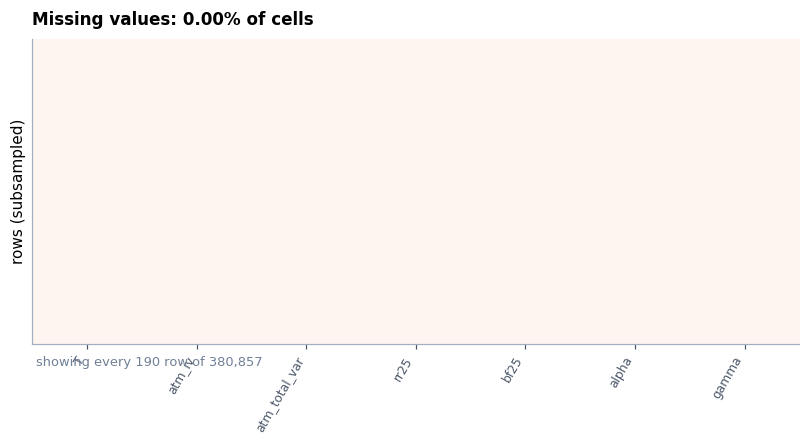

In [28]:
from rvlab.plotting import missingness_map

missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].to_string() if (missing > 0).any() else "no missing values")
missingness_map(df[["T", "atm_iv", "atm_total_var", "rr25", "bf25", "alpha", "gamma"]]);

Vertical stripes mean a column is broken; horizontal bands mean whole timestamps are missing. If the map is blank, the extraction upstream already dropped incomplete slices — which is itself worth knowing, because it means **the missingness is not in this frame, it is in the rows that never made it here**. Selection you cannot see is still selection.

In [29]:
expected_per_ts = df.groupby("ts", observed=True).size()
print(f"expiries per timestamp: min {expected_per_ts.min()}, "
      f"median {expected_per_ts.median():.0f}, max {expected_per_ts.max()}")

expiries per timestamp: min 4, median 12, max 13


## R1.16 · Choose an imputation strategy on purpose
<a id="r1-16"></a>

**Topic** Missing data

**Use when** you have gaps and need numbers. The three sklearn imputers make different assumptions, and the right one depends on why the value is missing.

**Inputs** a numeric frame with NaNs.

**Needs** nothing beyond the setup and data cells

**Gotchas** every imputer here **learns from the data it is fitted on**. Fitting on the whole frame before splitting leaks test information into training. Use them inside a pipeline — see [R3.4](forecasting_the_smile.ipynb#r3-4).

**See also** [R1.15](#r1-15) (patterns) · [R3.4](forecasting_the_smile.ipynb#r3-4) (inside a pipeline)

In [30]:
import numpy as np, pandas as pd
from sklearn.impute import KNNImputer, SimpleImputer

demo = df[["atm_iv", "rr25", "bf25"]].head(400).copy()
demo.iloc[::37, 1] = np.nan          # plant gaps so the comparison is visible
print(f"planted {demo.isna().sum().sum()} missing values")
demo.head(3)

planted 11 missing values


,atm_iv,rr25,bf25
0,0.1246,NaN,0.0033
1,0.1278,-0.0341,0.0026
2,0.1159,-0.0339,0.0045


`SimpleImputer(median)` ignores the other columns — safe, blunt, and it compresses variance. `KNNImputer` uses the correlated columns, which is better when features move together (they do here) and much slower. A missingness *indicator* is often worth more than either: it lets a model learn that the gap itself was informative.

In [31]:
filled = {
    "median": SimpleImputer(strategy="median").fit_transform(demo)[:, 1],
    "knn5":   KNNImputer(n_neighbors=5).fit_transform(demo)[:, 1],
}
truth = df["rr25"].head(400).to_numpy()
gaps = demo["rr25"].isna().to_numpy()

pd.DataFrame({k: {"rmse_on_gaps": float(np.sqrt(np.mean((v[gaps] - truth[gaps]) ** 2)))}
              for k, v in filled.items()}).T

,rmse_on_gaps
median,0.0087
knn5,0.0014


## R1.17 · Winsorize rather than delete
<a id="r1-17"></a>

**Topic** Outliers

**Use when** a column has extreme values that are more likely bad data than real events. Clipping to quantiles keeps the observation and limits its leverage; deleting the row throws away the columns that were fine.

**Inputs** `df`, and the quantiles in `WINSOR_Q`.

**Needs** nothing beyond the setup and data cells

**Gotchas** clipping is a **fitted** operation — the quantiles come from data. Learn them on the training fold only. And be honest that clipping at 1%/99% by construction removes 2% of your observations from the tails, which is exactly where a volatility model is most interesting.

**See also** [R1.14](#r1-14) (distributions) · [R3.5](forecasting_the_smile.ipynb#r3-5) (as a pipeline step)

In [32]:
from rvlab.pipelines import Winsorizer

cols = ["atm_iv", "rr25", "bf25"]
clipped = Winsorizer(lower=WINSOR_Q[0], upper=WINSOR_Q[1]).fit_transform(df[cols])

comparison = df[cols].agg(["std", "min", "max"]).T.add_prefix("raw_")
comparison.join(clipped.agg(["std", "min", "max"]).T.add_prefix("clipped_")).round(4)

,raw_std,raw_min,raw_max,clipped_std,clipped_min,clipped_max
atm_iv,0.0233,0.0792,0.2574,0.0228,0.0985,0.2092
rr25,0.0128,-0.1084,-0.0095,0.0126,-0.0845,-0.0252
bf25,0.0020,-0.0244,0.0372,0.0019,-0.0000,0.0089


> ⚠️ **Judgement:** the standard deviation drops because you removed the tails, not because the data got cleaner. Winsorizing is defensible for a feature fed to a squared-error model, and indefensible for estimating a tail risk.

In [33]:
share_clipped = (df[cols].rank(pct=True).lt(WINSOR_Q[0])
                 | df[cols].rank(pct=True).gt(WINSOR_Q[1])).mean()
share_clipped.to_frame("fraction clipped").round(4)

,fraction clipped
atm_iv,0.02
rr25,0.02
bf25,0.02


## R1.18 · Check quote sanity before trusting a derived value
<a id="r1-18"></a>

**Topic** Data quality

**Use when** any dataset with bid/ask. `bid <= mid <= ask` and a plausible spread are the two cheapest checks in derivatives data, and a violation invalidates every quantity computed downstream from that quote.

**Inputs** `chain` with `call_bid`, `call_mid`, `call_ask`.

**Needs** nothing beyond the setup and data cells

**Gotchas** a *wide* spread is not an error, it is illiquidity — and the mid of a very wide market is nearly meaningless even though it passes every bounds check. Filter on relative spread, not just on crossed quotes.

**See also** [R1.15](#r1-15) (missingness) · [R1.11](the_volatility_surface.ipynb#r1-11) (contracts)

In [34]:
import pandas as pd

crossed = (chain["call_bid"] > chain["call_ask"]).sum()
outside = (~chain["call_mid"].between(chain["call_bid"], chain["call_ask"])).sum()
rel_spread = (chain["call_ask"] - chain["call_bid"]) / chain["call_mid"]

pd.Series({"crossed markets": crossed, "mid outside bid/ask": outside,
           "median relative spread": round(float(rel_spread.median()), 4),
           "99th pct relative spread": round(float(rel_spread.quantile(0.99)), 4)}
          ).to_frame("value")

,value
crossed markets,0.0000
mid outside bid/ask,0.0000
median relative spread,0.0043
99th pct relative spread,0.0119


Relative spread is also a usability threshold. Quotes wider than a few percent carry an implied vol whose uncertainty swamps the signal you are trying to measure — a real consideration for the wings, which is precisely where `rr25` and `bf25` come from.

In [35]:
usable = rel_spread < 0.05
print(f"{usable.mean():.1%} of quotes have a relative spread under 5%")

100.0% of quotes have a relative spread under 5%


## R1.19 · Detect stale quotes
<a id="r1-19"></a>

**Topic** Data quality

**Use when** intraday data where a price can simply stop updating. A repeated value is not necessarily stale — but a long run of them is, and a run of unchanged prices creates artificial zero returns that bias every volatility estimate downward.

**Inputs** `chain` with a price column and a timestamp.

**Needs** nothing beyond the setup and data cells

**Gotchas** this bias matters directly for [R2.12](what_roughness_claims.ipynb#r2-12): the structure-function estimator of H is *downward* biased by exactly this kind of noise, so stale data makes volatility look rougher than it is.

**See also** [R1.18](#r1-18) (quote sanity) · [R2.12](what_roughness_claims.ipynb#r2-12) (estimator bias)

In [36]:
import numpy as np

px = chain["underlying_price"]
unchanged = px.diff() == 0
run_id = (~unchanged).cumsum()
runs = unchanged.groupby(run_id).sum()

print(f"{unchanged.mean():.1%} of bars are unchanged; longest run {int(runs.max())} bars")

2.4% of bars are unchanged; longest run 2 bars


The consequence, stated as a number: zero returns pull the realized-variance estimate down, because they contribute nothing to the sum of squares while still counting in the denominator.

In [37]:
r = np.log(px).diff().dropna()
naive = float(np.sqrt(r.pow(2).mean() * 390 * 252))
nonzero = float(np.sqrt(r[r != 0].pow(2).mean() * 390 * 252))
print(f"annualized RV including zero returns {naive:.4f}  vs excluding {nonzero:.4f}")

annualized RV including zero returns 0.0901  vs excluding 0.0912


## R1.20 · Resample an irregular panel without inventing observations
<a id="r1-20"></a>

**Topic** Resampling

**Use when** you want a coarser frequency. Subsampling keeps real observations; aggregating creates an average smile that never traded.

**Inputs** `df` with a `ts` column.

**Needs** nothing beyond the setup and data cells

**Gotchas** `resample().mean()` is the reflex and it is wrong for a *state* variable like an implied vol surface. Averaging is right for flows (volume, returns) and wrong for levels you intend to trade at.

**See also** [R3.10](forecasting_the_smile.ipynb#r3-10) (horizon choice) · [R4.9](when_a_result_is_real.ipynb#r4-9) (frequency sweeps)

In [38]:
from rvlab.features import resample_panel
import pandas as pd

rows = {f"{step}min": len(resample_panel(df, step)) for step in (1, 5, 15, 30, 60)}
pd.Series(rows).to_frame("rows retained")

,rows retained
1min,380857
5min,76701
15min,24831
30min,11880
60min,5924


Frequency is a real modelling choice, not a preprocessing detail. [R4.10](when_a_result_is_real.ipynb#r4-10) sweeps it, because a forecast that beats carry at 60 minutes and loses at 1 minute is telling you something about the horizon rather than about the model.

In [39]:
five = resample_panel(df, 5)
print(f"1min: {len(df):,} rows, {df['ts'].nunique():,} timestamps")
print(f"5min: {len(five):,} rows, {five['ts'].nunique():,} timestamps")

1min: 380,857 rows, 32,558 timestamps
5min: 76,701 rows, 6,561 timestamps


## R1.21 · Join two time series on time, correctly
<a id="r1-21"></a>

**Topic** Joins

**Use when** combining series sampled on different clocks. `merge_asof` matches each left row to the most recent right row at or before it — the only join that does not look into the future.

**Inputs** two frames, each sorted by its time key.

**Needs** nothing beyond the setup and data cells

**Gotchas** `direction='forward'` or `'nearest'` will happily match a row to data recorded *after* it. On any predictive task that is a leak, and it is invisible in the output.

**See also** [R3.2](forecasting_the_smile.ipynb#r3-2) (leakage taxonomy) · [R3.12](forecasting_the_smile.ipynb#r3-12) (purged CV)

In [40]:
import pandas as pd

left = df[["ts", "T", "atm_iv"]].drop_duplicates("ts").head(500).sort_values("ts")
right = chain[["timestamp_utc", "underlying_price"]].rename(
    columns={"timestamp_utc": "ts"}).sort_values("ts")

joined = pd.merge_asof(left, right, on="ts", direction="backward",
                       tolerance=pd.Timedelta(minutes=5))
joined.head(3)

,ts,T,atm_iv,underlying_price
0,2025-08-07 13:35:00+00:00,0.0192,0.1246,637.510
1,2025-08-07 13:36:00+00:00,0.0192,0.1246,637.365
2,2025-08-07 13:37:00+00:00,0.0192,0.1241,636.955


`tolerance` is what stops a stale match: without it, a gap in the right frame silently carries an hour-old price forward. Always check the match rate.

In [41]:
print(f"matched {joined['underlying_price'].notna().mean():.1%} of rows "
      f"within a 5-minute tolerance")

matched 100.0% of rows within a 5-minute tolerance


## R1.22 · Read a correlation matrix with the right correlation
<a id="r1-22"></a>

**Topic** Correlation

**Use when** before feature selection or any linear model. Spearman ranks are robust to the heavy tails that dominate volatility data; Pearson can be created or destroyed by a handful of bad quotes.

**Inputs** `df` with numeric columns.

**Needs** nothing beyond the setup and data cells

**Gotchas** `T` correlates with everything here, because it is a *scaling* variable rather than a predictor — `rr25` and `bf25` are defined with maturity in them. That is structure, not information, and [R3.1](forecasting_the_smile.ipynb#r3-1) shows how to divide it out.

**See also** [R4.4](when_a_result_is_real.ipynb#r4-4) (PCA) · [R3.1](forecasting_the_smile.ipynb#r3-1) (feature construction)

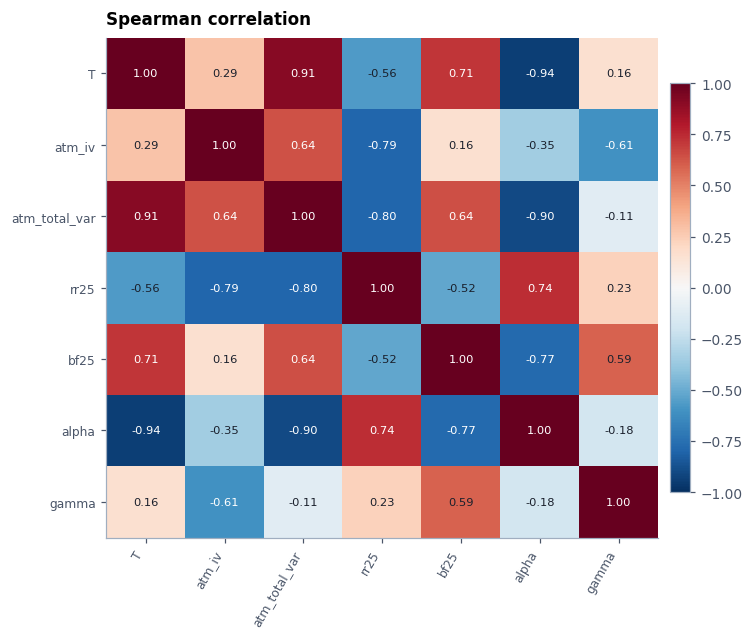

In [42]:
from rvlab.plotting import correlation_heatmap

correlation_heatmap(df[["T", "atm_iv", "atm_total_var", "rr25", "bf25", "alpha", "gamma"]],
                    method=CORR_METHOD);

How much the choice of method matters, on this data:

In [43]:
cols = ["T", "atm_iv", "rr25", "bf25"]
gap = (df[cols].corr("pearson") - df[cols].corr("spearman")).abs().max().max()
print(f"largest |Pearson - Spearman| disagreement: {gap:.3f}")

largest |Pearson - Spearman| disagreement: 0.101


## R1.23 · Plot the object you are actually modelling
<a id="r1-23"></a>

**Topic** Visualisation

**Use when** before any modelling. For this series that is the smile: implied vol against maturity, at one instant, across every expiry quoted.

**Inputs** `df` — one timestamp's cross-section.

**Needs** nothing beyond the setup and data cells

**Gotchas** pick the *widest* cross-section, not the first. The number of expiries quoted varies through the day, and a thin slice makes the term structure look smoother than it is.

**See also** [R2.9](what_roughness_claims.ipynb#r2-9) (fitting the term structure)

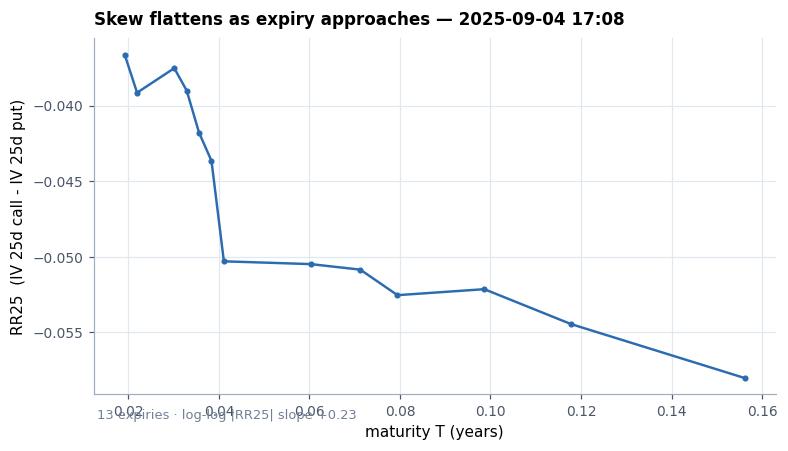

In [44]:
import numpy as np
from rvlab.features import widest_cross_section
from rvlab.plotting import term_structure_plot

slice_ = widest_cross_section(df)
skew_slope = np.polyfit(np.log(slice_["T"]), np.log(slice_["rr25"].abs()), 1)[0]
shape = "steepens" if skew_slope < 0 else "flattens"
term_structure_plot(slice_, y="rr25",
                    title=f"Skew {shape} as expiry approaches — {slice_['ts'].iloc[0]:%Y-%m-%d %H:%M}",
                    ylabel="RR25  (IV 25d call - IV 25d put)",
                    note=f"{len(slice_)} expiries · log-log |RR25| slope {skew_slope:+.2f}");

This picture is the whole empirical question of the series. `rr25` is negative, but whether its magnitude steepens or flattens toward short maturity is an empirical result, reported in the caption rather than assumed. Rough H = 0.10 predicts a log-log exponent of −0.40; [R2.9](what_roughness_claims.ipynb#r2-9) tests it.

In [45]:
print(slice_[["T", "atm_iv", "rr25", "bf25"]]
      .assign(dte=lambda d: (d["T"] * 365).round(0)).head(6).to_string(index=False))

     T  atm_iv    rr25   bf25  dte
0.0192  0.1187 -0.0366 0.0022  7.0
0.0219  0.1200 -0.0391 0.0018  8.0
0.0301  0.1078 -0.0375 0.0043 11.0
0.0329  0.1094 -0.0390 0.0048 12.0
0.0356  0.1160 -0.0418 0.0054 13.0
0.0384  0.1141 -0.0437 0.0096 14.0


## Verdict & what carries forward

Three sections, and the through-line is that nothing here was taken on trust: the environment was checked, the file was checked, and the features were checked before a single model saw them.

### Orientation

The environment is verified and you know how to find things. Two conventions are worth
carrying with you:

* **Provenance travels with the data.** Any frame from `rvlab.data` records where it came
  from and whether it is synthetic. Check it before quoting a number.
* **A recipe is self-contained.** Every `R<n>` block uses only `df`, the parameters cell,
  and what it defines itself, and carries its own imports. This is enforced by
  `scripts/lint_notebooks.py --copy-paste-test`, not merely intended, so you can lift any
  one of them into another project.

Next in this notebook: **What is being observed**.

**The programme, one line per notebook.** Orient the data · state the rough-volatility
claim · turn it into a leak-free forecast · attack the result · transfer the design to a
cross-section · audit where numbers came from · display and join evidence · connect
volatility estimates to positions · reuse the whole method as a competition workbench.

### What is being observed

We have a smile panel whose provenance, schema and coverage are all stated rather than
assumed. Two facts from this notebook constrain everything that follows:

* **Coverage.** The panel quotes roughly a dozen expiries at each timestamp, spanning 7 to
  60 days. That cross-section is what makes the maturity-scaling test in [R2.9](what_roughness_claims.ipynb#r2-9)
  possible — with one expiry per bar there would be nothing to regress against `T`.
* **Provenance.** Whether these numbers are real SPY quotes or a synthetic stand-in is
  recorded on the frame, not in someone's memory. Every later claim inherits that flag.

Next in this notebook: **The first look, and where the hypothesis comes from**, where we find out
how much of this data is actually usable — and what a stale quote does to an implied vol.

### The first look

The panel is usable, with three caveats that follow us forward:

* **Derived, not observed.** Every smile feature comes from inverting a quoted price. Quote
  quality is therefore feature quality, and the wings — where `rr25` and `bf25` live — are
  the least liquid part of the chain.
* **Invisible selection.** The missingness map is nearly blank, which does not mean nothing
  was dropped. It means slices that failed to invert never reached this frame. Selection you
  cannot see is still selection.
* **Stale quotes bias volatility downward**, and [R2.12](what_roughness_claims.ipynb#r2-12)'s estimator of H is biased
  downward by exactly that kind of noise. Some of the "roughness" in this literature is
  measurement error, and we will demonstrate that rather than assert it.

The last plot is the question in visual form: skew is negative, and its measured maturity
slope decides whether the rough prediction survives. Next: [What Roughness Claims](what_roughness_claims.ipynb).